In [1]:
import os
import re
import sys
import time
import getopt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.append("/home/users/mnergiz/softwares/licsar_extra/python")  # adjust as needed
import datetime as dt
from lics_tstools import load_licsbas_cumh5_as_xrda
from lics_tstools import generate_pmm_velocity
from lics_tstools import load_tif2xr
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
from plotting_LOS_GNSS import *

snaphu not detected. please install it yourself, e.g. from:
https://web.stanford.edu/group/radar/softwareandlinks/sw/snaphu
setting pyproj data directory
licsar misc not loaded
licsbas not loaded - the amplitude/coherence average/stability will fail


In [ ]:
os.environ["LiCSAR_public"] = "/gws/ssde/j25a/nceo_geohazards/vol1/public/LiCSAR_products.public/"
frame="021D_05266_252525"
sbovl=False
path="/work/scratch-pw4/licsar/mnergiz/TR_postseismic_13032026/reunw/021D_05266_252525"
TS_folder = "/work/scratch-pw4/licsar/mnergiz/TR_postseismic_13032026/reunw/021D_05266_252525/TS_GEOCml10GACOS"
GEOC_folder = os.path.join(os.path.dirname(os.path.normpath(TS_folder)), "GEOCml10GACOS")
cumfile=f"{TS_folder}/cum.h5"
cumfile_filt=f"{TS_folder}/cum_filt.h5"

cum = load_licsbas_cumh5_as_xrda(cumfile)
cum_filt = load_licsbas_cumh5_as_xrda(cumfile_filt)

ref_loc = "KLS1"
point_loc = "MLY1"

gnss_cum=xr.open_dataset("/gws/ssde/j25a/nceo_geohazards/vol2/LiCS/temp/insar_proc/mnergizci/GNSS_Turkey_Ergintav/gnss_nc.nc")
gnss_ref = reference_gnss_dataset(
    gnss_cum,
    reference_station=ref_loc,
    vars_to_ref=("Ve", "Vn", "Vu"),
    verbose=True,
)

#ENU unit vectors
if sbovl:
    E_unit=load_tif2xr(f'{path}/{frame}.E.azi.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.azi.geo.tif')
    # azimuth has no vertical sensitivity
    U_unit = xr.zeros_like(E_unit)
else:
    E_unit=load_tif2xr(f'{path}/{frame}.E.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.geo.tif')
    U_unit=load_tif2xr(f'{path}/{frame}.U.geo.tif')


gnss_los = project_gnss_to_los(
    gnss_ref,
    E_unit=E_unit,
    N_unit=N_unit,
    U_unit=U_unit,
    method="nearest",
    sboi=False,
    los_name="gnss_los",
)

df, t = los_points_at_time(
    gnss_los,
    var="gnss_los",
    t=gnss_los.time.values[-1],   # or any epoch
)

reference = get_station_coords(gnss_ref, ref_loc)
point1    = get_station_coords(gnss_ref, point_loc)

# #plotting and reference points
# if sbovl:
#     reference=(37, 35.55) #lon lat
#     point1=(37.55, 38.55) #lon lat
# else:
#     reference=(37, 35.5) #lon lat
#     point1=(36.7, 38.2) #lon lat
    

getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


Referenced 'Ve' to first epoch and station 'KLS1'
Referenced 'Vn' to first epoch and station 'KLS1'
Referenced 'Vu' to first epoch and station 'KLS1'
1.8726899383983573


In [3]:
if sbovl:
    vars_to_ref = ["cum"]
else:
    vars_to_ref = ["cum"]

cum_ref = reference_ts_dataset(
    cum,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=True,
    halfwin=4,
    verbose=True
)

cum_filt_ref = reference_ts_dataset(
    cum_filt,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=True,
    halfwin=4,
    verbose=True
)

Referenced 'cum' using nearest pixel
Referenced 'cum' using nearest pixel


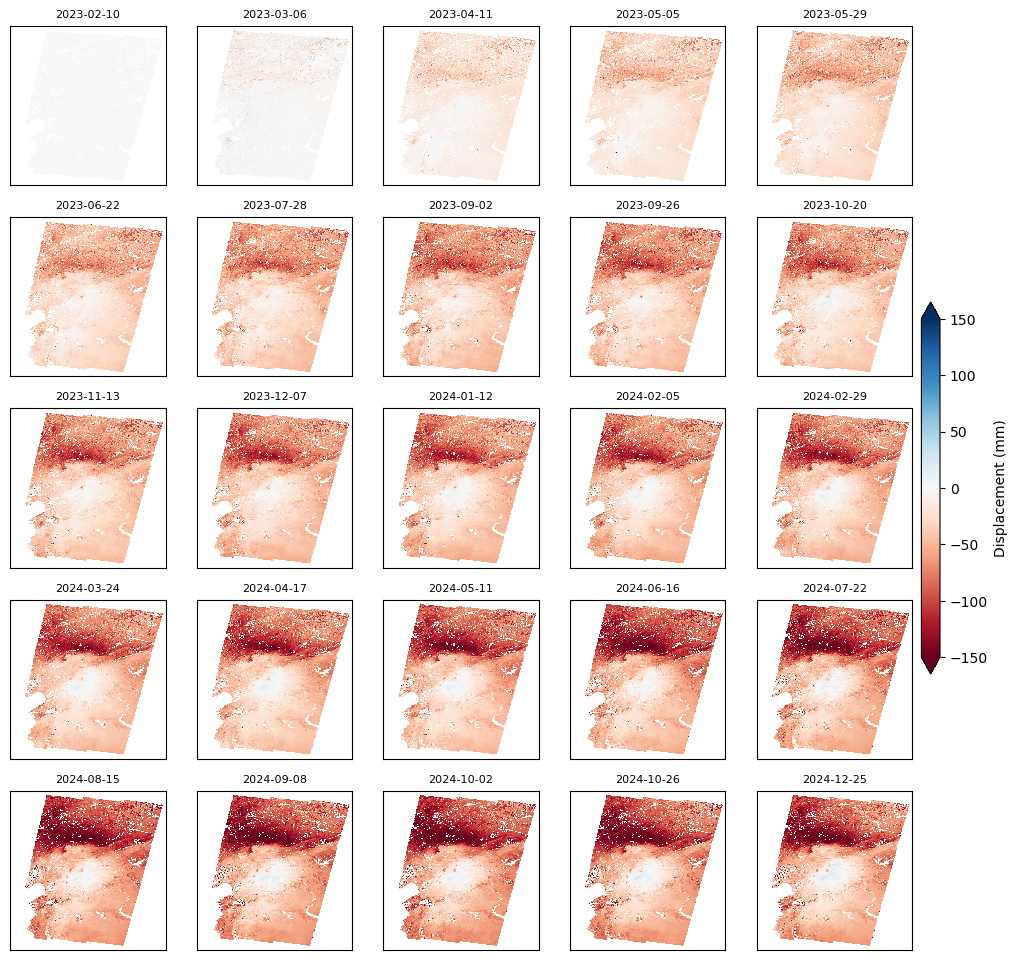

In [4]:
###########
nplots = 25
times = cum_filt_ref.time.values

idx = np.linspace(0, len(times)-1, nplots, dtype=int)
da_sel = cum_filt_ref.cum.isel(time=idx)

#########
ncols = 5
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 12))

vmin, vmax = -150, 150

for i, ax in enumerate(axes.flat):
    if i >= nplots:
        ax.axis("off")
        continue

    im = da_sel.isel(time=i).plot(
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap="RdBu",
        add_colorbar=False
    )

    # title as date
    t = da_sel.time.values[i]
    ax.set_title(str(t)[:10], fontsize=8)

    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.set_xlabel("")
    ax.set_ylabel("")


# ---- shared colorbar (right side) ----
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.02,   # width of colorbar
    pad=0.01,         # space between plots and colorbar
    extend="both"
)
cbar.set_label("Displacement (mm)")

# plt.tight_layout()
plt.savefig("cum_filt_021D.png")
plt.show()

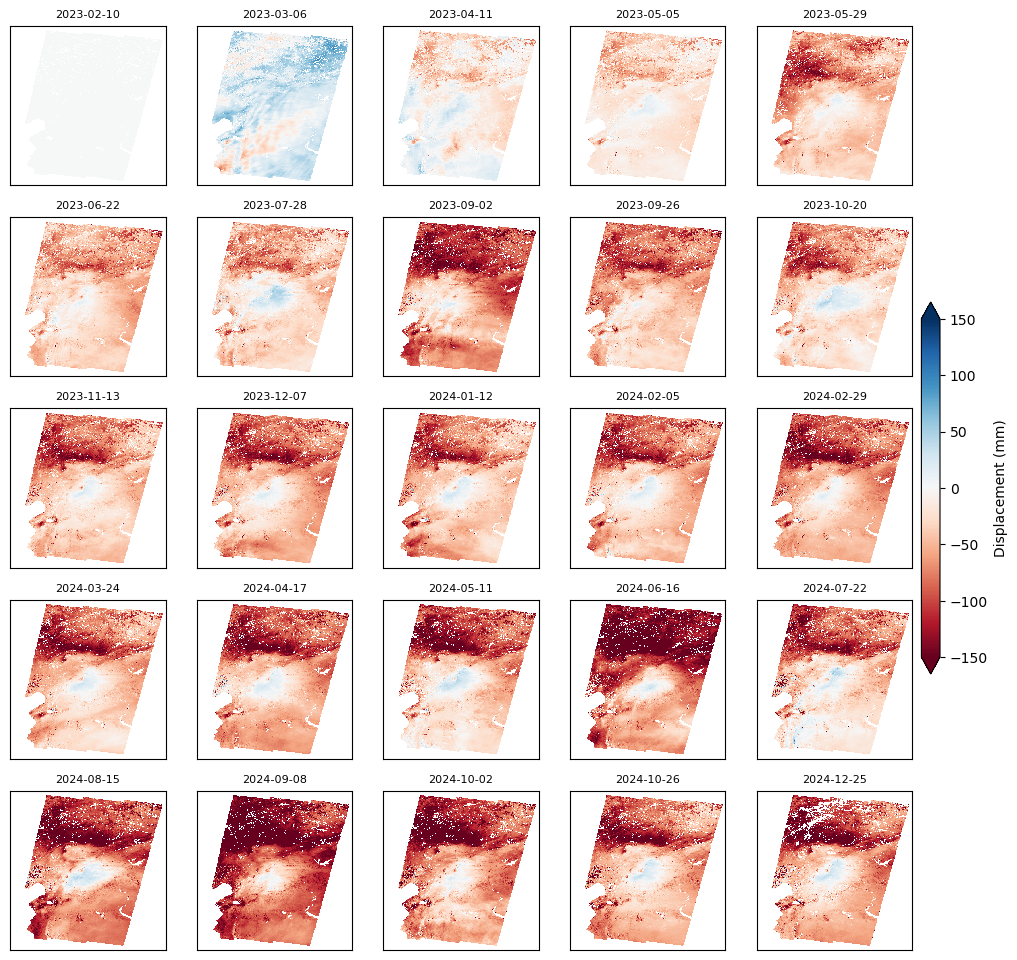

In [5]:
import matplotlib.pyplot as plt

###########
nplots = 25
times = cum_ref.time.values

idx = np.linspace(0, len(times)-1, nplots, dtype=int)
da_sel = cum_ref.cum.isel(time=idx)

#########
ncols = 5
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 12))

vmin, vmax = -150, 150

for i, ax in enumerate(axes.flat):
    if i >= nplots:
        ax.axis("off")
        continue

    im = da_sel.isel(time=i).plot(
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap="RdBu",
        add_colorbar=False
    )

    # title as date
    t = da_sel.time.values[i]
    ax.set_title(str(t)[:10], fontsize=8)

    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.set_xlabel("")
    ax.set_ylabel("")

# ---- shared colorbar (right side) ----
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.02,   # width of colorbar
    pad=0.01,         # space between plots and colorbar
    extend="both"
)
cbar.set_label("Displacement (mm)")


# plt.subplots_adjust(right=1)
plt.savefig("cum_021D.png")
plt.show()

In [6]:
time_years = xr.DataArray(
    (cum.time.values - cum.time.values[0]) / np.timedelta64(1, 'D') / 365.25,
    coords={"time": cum.time.values},
    dims=["time"]
)

# -------------------------
# Plate motion correction
# -------------------------
vlos_eurasia = generate_pmm_velocity(frame, 'Eurasia', 'GEOC', azi=sbovl)
vlos_eurasia_reshaped = vlos_eurasia.interp_like(cum.vel)

plate_motion_cumulative = vlos_eurasia_reshaped * time_years

# -------------------------
# Interseismic correction
# -------------------------
#interseismic model
ve_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/decomp3d.nc'
vn_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/velmap_insars29_sbois0_scalar.nc'
# #ENU unit vectors
# if sbovl:
#     E_unit=load_tif2xr(f'{path}/{frame}.E.azi.geo.tif')
#     N_unit=load_tif2xr(f'{path}/{frame}.N.azi.geo.tif')
#     # azimuth has no vertical sensitivity
#     U_unit = xr.zeros_like(E_unit)
# else:
#     E_unit=load_tif2xr(f'{path}/{frame}.E.geo.tif')
#     N_unit=load_tif2xr(f'{path}/{frame}.N.geo.tif')
#     U_unit=load_tif2xr(f'{path}/{frame}.U.geo.tif')


ve_gnss = xr.load_dataset(ve_gnss_nc).Ve
vn_gnss = xr.load_dataset(vn_gnss_nc).Vn

ve_gnss_reshaped = ve_gnss.interp_like(E_unit)
vn_gnss_reshaped = vn_gnss.interp_like(E_unit)

interseismic_velo = ve_gnss_reshaped * E_unit + vn_gnss_reshaped * N_unit
interseismic_velo_reshaped = interseismic_velo.interp_like(cum.vel)
interseismic_velo_cumulative = interseismic_velo_reshaped * time_years

assume a spheroidal Earth as defined in WGS84
Interpolating the plate velocity ENU vectors to the original frame resolution
Calculating the plate motion velocity in LOS (please check the sign here)


In [7]:
ds_plate = xr.Dataset({"plate": plate_motion_cumulative})
ds_plate_ref = reference_ts_dataset(
    ds_plate,
    reference=reference,
    vars_to_ref=["plate"],
    use_nearest=True,
    halfwin=4,
    verbose=True
)

ds_inter = xr.Dataset({"interseismic": interseismic_velo_cumulative})
ds_inter_ref = reference_ts_dataset(
    ds_inter,
    reference=reference,
    vars_to_ref=["interseismic"],
    use_nearest=True,
    halfwin=4,
    verbose=True
)

plate_motion_cumulative_ref = ds_plate_ref["plate"]
interseismic_velo_cumulative_ref = ds_inter_ref["interseismic"]

Referenced 'plate' using nearest pixel
Referenced 'interseismic' using nearest pixel


In [8]:
cum_ts = extract_ts_window_mean(cum_ref.cum, point1, halfwin=4).values
cum_filt_ts = extract_ts_window_mean(cum_filt_ref.cum, point1, halfwin=4).values

gnss_los_ts = gnss_los["gnss_los"].sel(station=point_loc).values

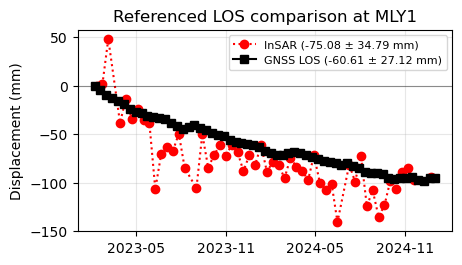

In [9]:
cm = 1 / 2.54  # inches per cm

fig, ax = plt.subplots(1, 1, figsize=(12*cm, 7*cm))

plt.rcParams["legend.fontsize"] = 8

# -------------------------
# statistics
# -------------------------
mean_cum = np.nanmean(cum_ts)
std_cum  = np.nanstd(cum_ts)

mean_cum_filt = np.nanmean(cum_filt_ts)
std_cum_filt  = np.nanstd(cum_filt_ts)

mean_gnss = np.nanmean(gnss_los_ts)
std_gnss  = np.nanstd(gnss_los_ts)


time_insar = cum_ref.time.values
time_gnss = gnss_los.time.values
# -------------------------
# InSAR
# -------------------------
ax.plot(
    time_insar, cum_ts,
    color="red", marker="o", linestyle=":",
    label=f"InSAR ({mean_cum:.2f} ± {std_cum:.2f} mm)"
)

# ax.plot(
#     time_insar, cum_filt_ts,
#     color="green", marker="o", linestyle="-",
#     label=f"InSAR filtered ({mean_cum_filt:.2f} ± {std_cum_filt:.2f} mm)"
# )

# -------------------------
# GNSS
# -------------------------
ax.plot(
    time_gnss, gnss_los_ts,
    color="black", marker="s", linestyle="-",
    label=f"GNSS LOS ({mean_gnss:.2f} ± {std_gnss:.2f} mm)"
)

# -------------------------
# formatting
# -------------------------
ax.set_title(f"Referenced LOS comparison at {point_loc}")
ax.set_ylabel("Displacement (mm)")

# zero line (important)
ax.axhline(0, color="k", lw=0.8, alpha=0.4)

# x-axis formatting
locator = mdates.MonthLocator(interval=6)
formatter = mdates.DateFormatter("%Y-%m")

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.grid(True, alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

In [10]:
corrected_cum = (
    cum_ref.cum.isel(time=-1)
)

DEM already exists!


getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


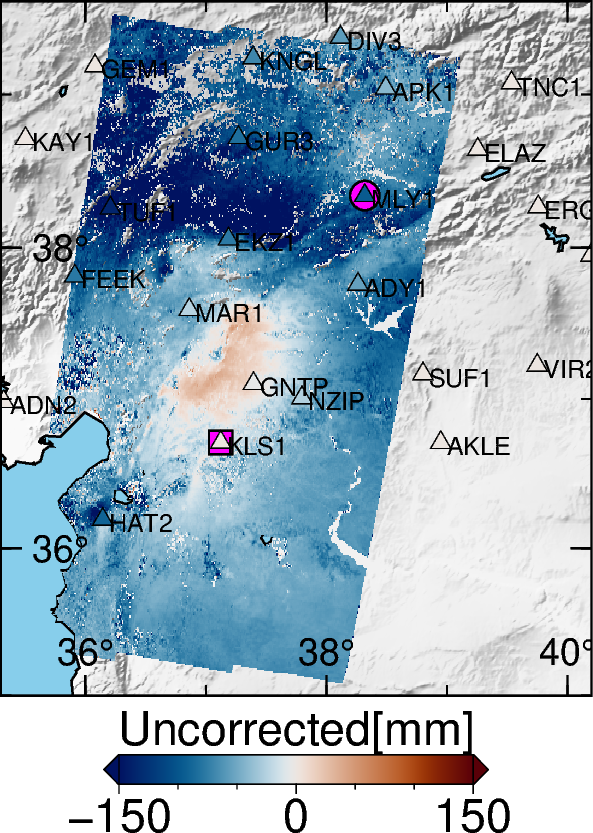

In [11]:
import pygmt
##DEM file
dem_file='earth_relief_fullAHB_30s.nc'
batchdir = os.environ.get("BATCH_CACHE_DIR")
dem = os.path.join(batchdir, dem_file)
#####
# DEM downloading
if not os.path.exists(dem):
    print('DEM is downloading please wait! After downloading, the process will be faster!')
    try:
        lonmin_lamb = 1  # degrees East
        lonmax_lamb = 80
        latmin_lamb = 25
        latmax_lamb = 60
        RR_used = [lonmin_lamb, lonmax_lamb, latmin_lamb, latmax_lamb]
        dem_resolution='30s'
        # Download the earth relief data and save it to a file
        grid = pygmt.datasets.load_earth_relief(resolution=dem_resolution, region=RR_used)
        # Saving the grid to a NetCDF file
        grid.to_netcdf(dem)
        print(f"Data successfully downloaded and saved to {dem}")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f'DEM already exists!')

##fault file
# GEMS_dir='/scratch/eemne/GEMS'
# fault_file=f'{GEMS_dir}/actives/TR_active_faults.shp'

#plot region
# plot_region = [35.3, 39.2, 35, 39.6]
plot_region = [35.3, 40.2, 35, 39.6]
#####
fig = pygmt.Figure()
pygmt.config(
    MAP_FRAME_TYPE="plain",
    FONT_ANNOT_PRIMARY="20p,Helvetica,black",   # longitude ticks
    FONT_LABEL="20p,Helvetica,black",       # axis labels
    FORMAT_GEO_MAP='D',
    MAP_FRAME_PEN="0.5p,black",  # 2-point thick black frame line
    MAP_DEFAULT_PEN="0.5p,black",
    # MAP_TICK_PEN_PRIMARY="1p",
    # MAP_TICK_LENGTH_PRIMARY="5p",
    MAP_TICK_LENGTH="5p"
)
## Figure a --plotting Uncorrected deformation
#Plot background DEM
fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
fig.coast(shorelines="black", water="skyblue")
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
fig.grdimage(grid=corrected_cum , cmap=cmap, region=plot_region, nan_transparent=True)


###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a150f50+lUncorrected[mm]',  # Label for the color bar
    cmap=True,
    position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# plotting reference points
# circle for point1
fig.plot(
    x=point1[0],
    y=point1[1],
    style="c0.25c",      # circle, diameter 0.25 cm
    fill="magenta1",
    pen="0.5p,black"
)

# rectangle for reference point
fig.plot(
    x=reference[0],
    y=reference[1],
    style="r0.20c/0.20c",  # rectangle width/height
    fill="magenta1",
    pen="0.5p,black"
)

dfD = df.dropna()
fig.plot(
    x=dfD["lon"].values,
    y=dfD["lat"].values,
    style="t0.2c",
    fill=dfD["v"].values,
    cmap=True,
    pen="0.2p,black",
)


# add station names
for _, row in dfD.iterrows():
    fig.text(
        x=row["lon"],
        y=row["lat"],
        text=str(row["station"]),
        font="6p,Helvetica,black",
        justify="LT",   # Left-Top alignment (avoids overlap with marker)
        offset="0.05c/0.05c",
    )

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])

fig.savefig(f"Figure3_cumulativerections_{point_loc}.png")
fig.show()
